In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from scipy.sparse import linalg
import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.providers.fake_provider import GenericBackendV2

### __INISIALISASI__ ###

In [2]:
#membuat list untuk 17 panjang ikatan untuk moelkul hidrogen
bond_lengths = np.array([
    #repulsive region
    0.5, 0.6, 0.65, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.85, 0.9, 0.95,
    #region dari thesis
    1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])

#membuat array kosong untuk menyimpan energi ground state hasil simulasi pada panjang ikatan yg berbeda
energies_exact = []
energies_sv = []
energies_aer = []
energies_hw = []

In [5]:
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))

 bond_length   E_exact     E_vqe  iterations
      0.5000 -1.055160 -1.020089          33
      0.6000 -1.116286 -1.086449          34
      0.6500 -1.129905 -1.102316          33
      0.7000 -1.136189 -1.110625          35
      0.7200 -1.137112 -1.112298          33
      0.7400 -1.137284 -1.113189          34
      0.7600 -1.136796 -1.113390          34
      0.7800 -1.135727 -1.112982          35
      0.8000 -1.134148 -1.112035          35
      0.8500 -1.128362 -1.107719          34
      0.9000 -1.120560 -1.101242          35
      0.9500 -1.111339 -1.093216          36
      1.0000 -1.101150 -1.084108          36
      1.2000 -1.056741 -1.043077          38
      1.3000 -1.035186 -1.022742          34
      1.3900 -1.017339 -1.005769          36
      1.4000 -1.015468 -1.003983          36
      1.4011 -1.015264 -1.003788          34
      1.4100 -1.013622 -1.002220          35
      1.5000 -0.998149 -0.987398          41
      1.6000 -0.983473 -0.973261          34
      1.80

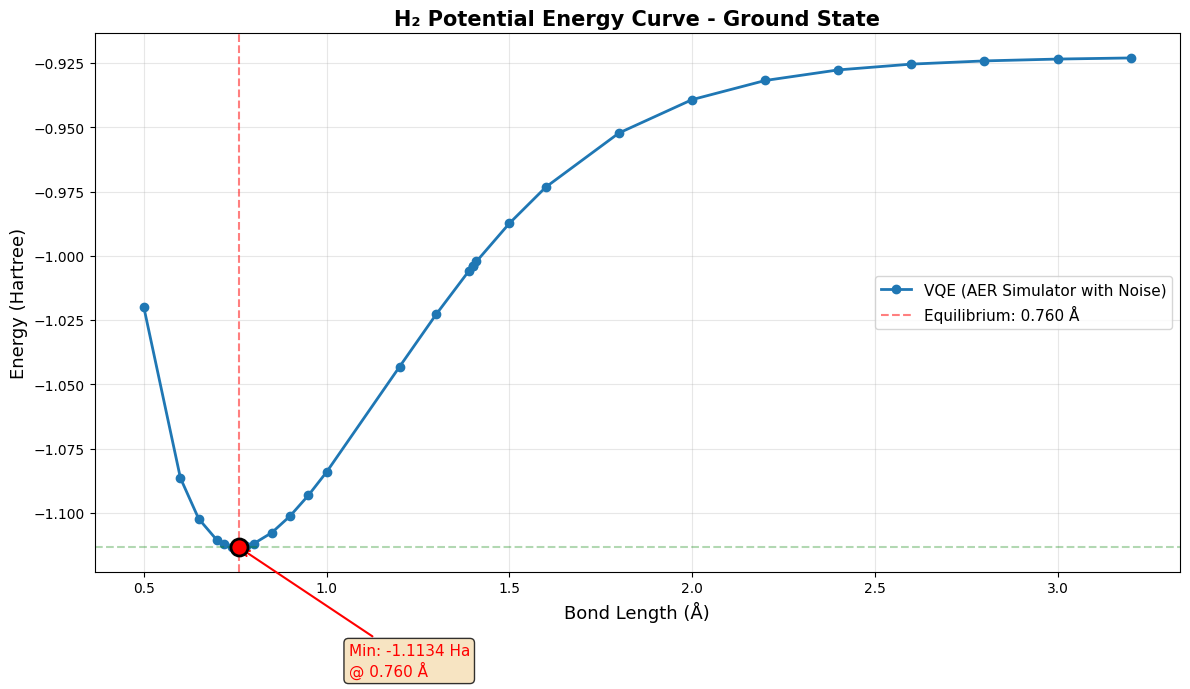


Equilibrium bond length: 0.7600 Å
Minimum energy (ground state): -1.113390 Ha


In [6]:
bond_lengths_plot = np.array([r['bond_length'] for r in results])
energies = np.array([r['E_vqe'] for r in results])

min_idx = np.argmin(energies)
min_bond = bond_lengths_plot[min_idx]
min_energy = energies[min_idx]

plt.figure(figsize=(12, 7))
plt.plot(bond_lengths_plot, energies, 'o-', linewidth=2, 
         markersize=6, label='VQE (AER Simulator with Noise)')

# Mark minimum dengan garis vertikal dan horizontal
plt.axvline(min_bond, color='red', linestyle='--', alpha=0.5, 
            label=f'Equilibrium: {min_bond:.3f} Å')
plt.axhline(min_energy, color='green', linestyle='--', alpha=0.3)

# Annotate minimum point
plt.scatter([min_bond], [min_energy], color='red', s=150, 
            zorder=5, edgecolor='black', linewidth=2)
plt.annotate(f'Min: {min_energy:.4f} Ha\n@ {min_bond:.3f} Å',
             xy=(min_bond, min_energy),
             xytext=(min_bond + 0.3, min_energy - 0.05),
             fontsize=11, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.xlabel('Bond Length (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('H₂ Potential Energy Curve - Ground State', fontsize=15, weight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Equilibrium bond length: {min_bond:.4f} Å")
print(f"Minimum energy (ground state): {min_energy:.6f} Ha")
print(f"{'='*50}")